/tmp/ipykernel_1710377/1861356522.py:131: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0, right=1, bottom=0, top=1)


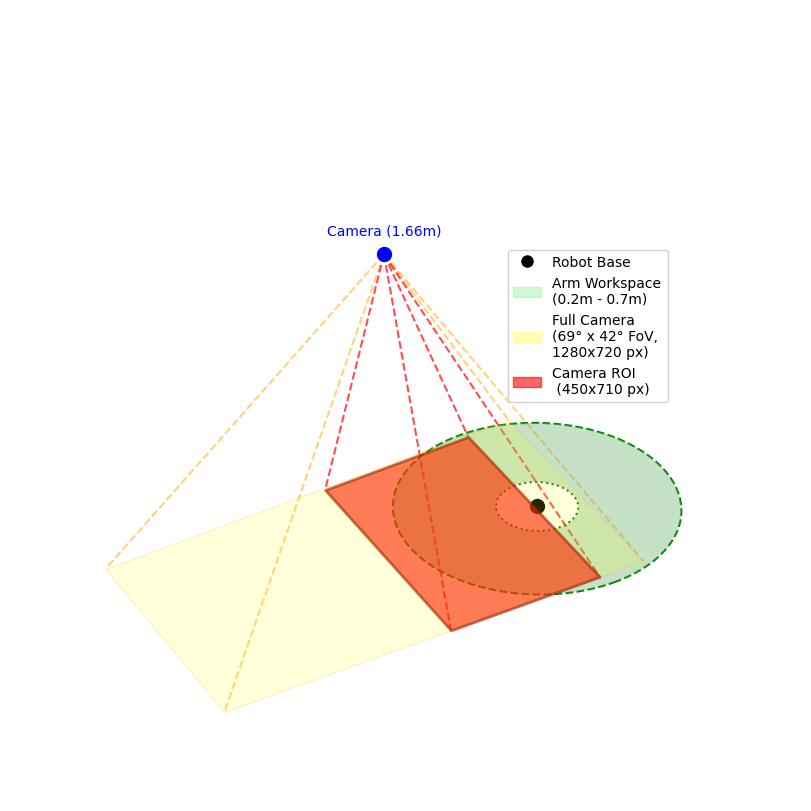

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# 1. Transformation matrix & Extraction
camera_to_base = np.array([
    [ 0.02108248,  0.99961317, -0.01813947,  0.02700487],
    [-0.99844435, -0.02198764, -0.05123886, -0.86255361],
    [-0.05161788, -0.01703101, -0.99852168,  1.66004511],
    [ 0.        ,  0.        ,  0.        ,  1.        ]
])

camera_pos = camera_to_base[:3, 3]
rotation_matrix = camera_to_base[:3, :3]

# 2. Camera properties (Full FoV)
W, H = 1280, 720
fov_h = np.deg2rad(69)
fov_v = np.deg2rad(42)

x_max = np.tan(fov_h / 2.0)
y_max = np.tan(fov_v / 2.0)

# Full FoV Corners
corners_local = np.array([
    [-x_max, -y_max, 1], [ x_max, -y_max, 1], 
    [ x_max,  y_max, 1], [-x_max,  y_max, 1]
])

# 3. Camera Region of Interest (ROI) Mapping (Mirrored X)
roi_x_min, roi_x_max = 700, 1150
roi_y_min, roi_y_max = 10, 720

roi_w = roi_x_max - roi_x_min
roi_h = roi_y_max - roi_y_min

def pixel_to_local(px, py):
    u = -(px - W/2) / (W/2)  # Flipped sign to mirror
    v = (py - H/2) / (H/2)
    return np.array([u * x_max, v * y_max, 1.0])

roi_corners_px = [
    (roi_x_min, roi_y_min), (roi_x_max, roi_y_min),
    (roi_x_max, roi_y_max), (roi_x_min, roi_y_max)
]
roi_corners_local = np.array([pixel_to_local(px, py) for px, py in roi_corners_px])

# 4. Ray casting function
def cast_to_table(local_corners):
    points = []
    for corner in local_corners:
        direction_world = rotation_matrix.dot(corner)
        t = -camera_pos[2] / direction_world[2]
        points.append(camera_pos + t * direction_world)
    return np.array(points)

table_points_full = cast_to_table(corners_local)
table_points_roi = cast_to_table(roi_corners_local)

# 5. Set up the 3D plot
fig = plt.figure(figsize=(10, 8), constrained_layout=True) 
ax = fig.add_subplot(111, projection='3d')
ax.set_axis_off()

# Plot Robot Base
ax.scatter(0, 0, 0, color='black', s=100)

# 6. Plot Robot Arm Workspace
theta = np.linspace(0, 2*np.pi, 100)
r_inner, r_outer = 0.2, 0.7
R_grid, Theta_grid = np.meshgrid(np.linspace(r_inner, r_outer, 20), theta)
X_ring = R_grid * np.cos(Theta_grid)
Y_ring = R_grid * np.sin(Theta_grid)
Z_ring = np.zeros_like(X_ring)

ax.plot_surface(X_ring, Y_ring, Z_ring, color='lightgreen', alpha=0.4)
ax.plot(r_outer*np.cos(theta), r_outer*np.sin(theta), 0, color='green', linestyle='--')
ax.plot(r_inner*np.cos(theta), r_inner*np.sin(theta), 0, color='darkgreen', linestyle=':')

# Plot Camera Position
# Plot Camera Position
ax.scatter(*camera_pos, color='blue', s=100)

# Create a formatted string holding the coordinates (rounded to 2 decimal places)
coord_text = f"Camera\n(x={camera_pos[0]:.2f}, y={camera_pos[1]:.2f}, z={camera_pos[2]:.2f})m"

# Add the text label slightly above the camera point
ax.text(camera_pos[0], camera_pos[1], camera_pos[2] + 0.1, coord_text, color='blue', ha='center', fontsize=10)

# 7. Plot Full Camera FoV
for pt in table_points_full:
    ax.plot([camera_pos[0], pt[0]], [camera_pos[1], pt[1]], [camera_pos[2], pt[2]], 
            color='orange', linestyle='--', linewidth=1.5, alpha=0.5)
shadow_poly_full = Poly3DCollection([table_points_full], alpha=0.15, facecolor='yellow', edgecolor='orange')
ax.add_collection3d(shadow_poly_full)

# 8. Plot Camera ROI
for pt in table_points_roi:
    ax.plot([camera_pos[0], pt[0]], [camera_pos[1], pt[1]], [camera_pos[2], pt[2]], 
            color='red', linestyle='--', linewidth=1.5, alpha=0.7)
shadow_poly_roi = Poly3DCollection([table_points_roi], alpha=0.6, facecolor='red', edgecolor='darkred', linewidths=2)
ax.add_collection3d(shadow_poly_roi)

# 9. Create Custom Legends
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Robot Base'),
    mpatches.Patch(color='lightgreen', alpha=0.4, label='Arm Workspace\n(0.2m - 0.7m)'),
    mpatches.Patch(color='yellow', alpha=0.3, label=f'Full Camera \n(69° x 42° FoV, \n{W}x{H} px)'),
    mpatches.Patch(color='red', alpha=0.6, label=f'Camera ROI\n ({roi_w}x{roi_h} px)')
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.62, 0.6), fontsize=10, framealpha=0.9)

# 10. Fix Aspect Ratio and Limits
all_x = np.concatenate([X_ring.flatten(), table_points_full[:,0], table_points_roi[:,0], [camera_pos[0], 0]])
all_y = np.concatenate([Y_ring.flatten(), table_points_full[:,1], table_points_roi[:,1], [camera_pos[1], 0]])

# Define the exact spans of the data
x_min, x_max_val = np.min(all_x)-0.1, np.max(all_x)+0.1
y_min, y_max_val = np.min(all_y)-0.1, np.max(all_y)+0.1

ax.set_xlim([x_min, x_max_val])
ax.set_ylim([y_min, y_max_val])
ax.set_zlim([0, 1.7])

# Force physical proportions to stop the plot from stretching/tilting weirdly
x_range = x_max_val - x_min
y_range = y_max_val - y_min
ax.set_box_aspect((x_range, y_range, 1.8)) 

# Adjusted viewing angle: Higher elevation (55) for a better top-down perspective, 
# and a shifted azimuth (-60) to look at it more squarely.
ax.view_init(elev=35, azim=-30)

plt.margins(0, 0, 0)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.savefig('tightest_cropped_plot.png', bbox_inches='tight', pad_inches=0, dpi=300)

In [26]:
from PIL import Image, ImageOps

def trim_white_borders(image_path):
    # Open the image generated by matplotlib
    im = Image.open(image_path)
    
    # Create a solid white background of the same size
    bg = Image.new("RGB", im.size, (255, 255, 255))
    
    # Paste the image onto the white background. 
    # If it has a transparency channel, use it as a mask to blend properly.
    if im.mode in ('RGBA', 'LA') or (im.mode == 'P' and 'transparency' in im.info):
        bg.paste(im, mask=im.convert('RGBA').split()[3])
    else:
        bg.paste(im)
        
    # Invert the flattened image. 
    # This turns the white background completely black (0, 0, 0).
    inverted_bg = ImageOps.invert(bg)
    
    # getbbox() automatically finds the bounding box of all non-black pixels!
    bbox = inverted_bg.getbbox()
    
    if bbox:
        # Crop the ORIGINAL image (preserving its original quality and transparency)
        cropped_im = im.crop(bbox)
        cropped_im.save(image_path)
        print(f"Successfully cropped! New size: {cropped_im.size}")
    else:
        print("The image appears to be genuinely entirely white or blank.")

# Run the function on your saved file
trim_white_borders('tightest_cropped_plot.png')

Successfully cropped! New size: (1734, 1467)
